# 2.4 — Convergencia binomial a Black-Scholes

## Motivación

En 2.2 construimos el árbol CRR y en la sección de validación observamos, sin explicarlo del todo, que su precio se acerca al de una fórmula cerrada conforme $n$ crece. Este notebook cierra ese círculo: mostramos **por qué** $n \to \infty$ lleva el árbol binomial al modelo de Black-Scholes (1973), a qué **velocidad** converge, y por qué esa convergencia no es monótona sino que **oscila** entre pasos pares e impares — un artefacto de discretización bien documentado (Leisen y Reimer, 1996; Diener y Diener, 2004) que además nos regala una técnica de aceleración casi gratis: la extrapolación de Richardson.

La idea central es que el log-precio del árbol bajo la medida neutral al riesgo $\mathbb{Q}$ es una suma de $n$ variables i.i.d. acotadas — exactamente el escenario del Teorema Central del Límite (0.1). Si los dos primeros momentos de esa suma **matchean** a los del movimiento browniano geométrico que define Black-Scholes, el CLT garantiza que la distribución terminal del árbol converge a la lognormal correcta, y con ella el precio de la opción. Cubrimos: (i) la derivación de matching de momentos y la aplicación del CLT; (ii) la tasa de convergencia $O(1/n)$ y el fenómeno de oscilación par/impar; (iii) extrapolación de Richardson $(n,2n)$; (iv) Black-Scholes enunciado como límite (la derivación completa vía SDE/PDE se hace en 3.1); (v) validación numérica en tres capas: fórmula BS inline vs. `QuantLib` (`AnalyticEuropeanEngine`), CRR($n=2000$) vs. BS, y Richardson vs. BS.

## 1. Convergencia en distribución: el CLT bajo $\mathbb{Q}$

### 1.1 El log-retorno por paso

Recordemos la parametrización CRR de 2.2: $\Delta t = T/n$, $u = e^{\sigma\sqrt{\Delta t}}$, $d=1/u$, y la probabilidad neutral al riesgo **exacta**
$$
p = \frac{e^{r\Delta t}-d}{u-d}.
$$
En cada paso el log-retorno $Y_i = \log(S_{t_i}/S_{t_{i-1}})$ toma únicamente dos valores bajo $\mathbb{Q}$:
$$
Y_i = \begin{cases} +\sigma\sqrt{\Delta t} & \text{con probabilidad } p \\ -\sigma\sqrt{\Delta t} & \text{con probabilidad } 1-p \end{cases}, \qquad Y_1,\dots,Y_n \text{ i.i.d. bajo } \mathbb{Q}.
$$
El log-precio terminal es la suma $\log(S_T/S_0) = \sum_{i=1}^n Y_i$ — una suma de $n$ variables i.i.d. acotadas, el escenario exacto del CLT (0.1, sección 3.2).

### 1.2 Matching de momentos

Escribimos $Y_i = (2B_i-1)\sigma\sqrt{\Delta t}$ con $B_i\sim\text{Bernoulli}(p)$, así que
$$
\mathbb{E}^{\mathbb{Q}}[Y_i] = (2p-1)\,\sigma\sqrt{\Delta t}, \qquad \text{Var}^{\mathbb{Q}}(Y_i) = \sigma^2\Delta t\big(1-(2p-1)^2\big).
$$
Expandiendo $p$ para $\Delta t\to 0$ (Taylor de $u,d,e^{r\Delta t}$ a orden $\Delta t$):
$$
p = \frac{1}{2} + \frac{1}{2}\frac{\left(r-\tfrac{1}{2}\sigma^2\right)\sqrt{\Delta t}}{\sigma} + O(\Delta t), \qquad \text{es decir} \qquad 2p-1 = \frac{\left(r-\tfrac{1}{2}\sigma^2\right)\sqrt{\Delta t}}{\sigma} + O(\Delta t).
$$
(Esta es precisamente la aproximación lineal que `QuantLib` usa como su fórmula de $p$, mencionada en 2.2 §7 — aquí aparece de forma natural como el término dominante de la expansión de la fórmula exacta.) Sustituyendo:
$$
\mathbb{E}^{\mathbb{Q}}[Y_i] = \left(r-\tfrac{1}{2}\sigma^2\right)\Delta t + O(\Delta t^{3/2}), \qquad \text{Var}^{\mathbb{Q}}(Y_i) = \sigma^2\Delta t - \underbrace{(2p-1)^2\sigma^2\Delta t}_{O(\Delta t^2)} = \sigma^2\Delta t + O(\Delta t^2).
$$
Sumando sobre los $n=T/\Delta t$ pasos (la suma de $n$ i.i.d. tiene media y varianza $n$ veces las de un término):
$$
n\,\mathbb{E}^{\mathbb{Q}}[Y_1] \;\xrightarrow[n\to\infty]{}\; \left(r-\tfrac{1}{2}\sigma^2\right)T, \qquad n\,\text{Var}^{\mathbb{Q}}(Y_1) \;\xrightarrow[n\to\infty]{}\; \sigma^2 T.
$$
Estos son **exactamente** la media y varianza del log-precio bajo la dinámica de Black-Scholes, $\log(S_T/S_0) \sim \mathcal{N}\big((r-\tfrac{1}{2}\sigma^2)T,\ \sigma^2 T\big)$ bajo $\mathbb{Q}$ — el árbol CRR fue construido (la elección $u=e^{\sigma\sqrt{\Delta t}}$ no es arbitraria) precisamente para que sus dos primeros momentos matcheen a los del modelo continuo.

### 1.3 Aplicación del CLT

Nótese que $Y_1,\dots,Y_n$ no son i.i.d. con una ley fija: su soporte $\pm\sigma\sqrt{\Delta t}$ y su probabilidad $p$ dependen de $\Delta t=T/n$, así que para cada $n$ tenemos una fila distinta de una **arreglo triangular** — el CLT clásico (0.1, Teorema 3.2, que asume $X_1,X_2,\dots$ i.i.d. de una única ley fija) no aplica literalmente aquí. La herramienta correcta es el **CLT de Lindeberg-Feller** para arreglos triangulares (Billingsley, 1995, Teorema 27.2; Durrett, 2019, Teorema 3.4.10), que solo pide que la varianza agregada converja a un límite finito y que se cumpla la condición de Lindeberg: para todo $\varepsilon>0$,
$$
\frac{1}{s_n^2}\sum_{i=1}^n \mathbb{E}\big[Y_{n,i}^2\,\mathbb{1}_{\{|Y_{n,i}|>\varepsilon s_n\}}\big] \xrightarrow[n\to\infty]{} 0, \qquad s_n^2 = \sum_{i=1}^n \text{Var}(Y_{n,i}).
$$
Aquí la condición se cumple trivialmente: los términos están uniformemente acotados por $\sigma\sqrt{\Delta t}\to 0$ mientras que $s_n^2\to\sigma^2 T>0$ (sección 1.2), así que para $n$ suficientemente grande $|Y_{n,i}|\leq\sigma\sqrt{\Delta t}<\varepsilon s_n$ para todo $i$ y el indicador se anula idénticamente — ninguna cola pesada que controlar, a diferencia del caso i.i.d. general donde Lindeberg es una condición no trivial. Con eso, Lindeberg-Feller da
$$
\sum_{i=1}^n Y_i \;\xrightarrow{d}\; \mathcal{N}\!\left(\left(r-\tfrac{1}{2}\sigma^2\right)T,\ \sigma^2 T\right) \qquad (n\to\infty),
$$
es decir $\log(S_T/S_0)$ converge en distribución a la lognormal correcta bajo $\mathbb{Q}$. Como el payoff de una opción europea es una función continua (call/put) o acotada de $S_T$, la convergencia en distribución de $S_T$ implica la convergencia de $\mathbb{E}^{\mathbb{Q}}[e^{-rT}\text{payoff}(S_T)]$ al precio de Black-Scholes — el precio CRR converge al precio BS.

## 2. Tasa de convergencia y oscilación par/impar

### 2.1 Orden $O(1/n)$

El CLT solo garantiza convergencia en el límite, no dice a qué velocidad. Refinamientos vía expansión de Edgeworth de la distribución binomial (que aproxima la normal límite con correcciones en potencias de $1/\sqrt{n}$) muestran que el error del precio CRR se descompone como
$$
C_n - C_{\text{BS}} = \frac{c_1}{n} + O\!\left(\frac{1}{n^2}\right),
$$
para una constante $c_1$ que depende de $(S_0,K,r,\sigma,T)$ pero no de $n$ — convergencia lineal en $1/n$, mucho más lenta que la $O(1/\sqrt{n})$ ingenua que uno esperaría de un CLT genérico, porque aquí se cancela el término $O(1/\sqrt{n})$ de la expansión de Edgeworth (es antisimétrico y se promedia a cero cuando el payoff es suave alrededor del strike).

### 2.2 El fenómeno de oscilación par/impar

Esa cancelación depende de **dónde cae el strike $K$ relativo a la malla de nodos terminales** $S_T(j) = S_0 u^{n-j}d^j = S_0 e^{(n-2j)\sigma\sqrt{\Delta t}}$, $j=0,\dots,n$. Con $S_0=K$ (nuestro caso ATM), el nodo central $j=n/2$ coincide **exactamente** con $K$ solo cuando $n$ es **par**; cuando $n$ es impar, no existe nodo central y el nodo más cercano a $K$ queda desplazado en $O(1/\sqrt{n})$ relativo al strike. Esa discrepancia de posición reintroduce el término de orden $O(1/\sqrt{n})$ de Edgeworth con signo alternante según la paridad de $n$ — el resultado es que la secuencia $(C_n)$ no converge monótonamente: forma **dos subsecuencias suaves** (pares e impares), cada una con su propia constante $c_1^{\text{par}}, c_1^{\text{impar}}$ y (en general) signo distinto, mientras la secuencia completa entrelazada oscila en zigzag alrededor de $C_{\text{BS}}$ (el mismo artefacto de paridad que 2.2 §5 filtra al graficar la frontera de ejercicio temprano solo en pasos pares).

Leisen y Reimer (1996) explotan esto: eligen una probabilidad $p_n$ distinta de la CRR clásica, calibrada para que el nodo más cercano al strike converja monótonamente a $K$ para todo $n$, eliminando la oscilación y logrando $O(1/n^2)$ sin necesidad de extrapolar. Diener y Diener (2004) dan el análisis asintótico riguroso completo (expansión de Edgeworth a todos los órdenes) que explica de dónde sale exactamente cada término.

### 2.3 Extrapolación de Richardson

Si restringimos a la subsecuencia par (donde el error es $c_1/n + O(1/n^2)$ sin el término oscilante), podemos **eliminar** el término $O(1/n)$ combinando dos evaluaciones $C_n$ y $C_{2n}$ (ambos pares si $n$ lo es):
$$
C_n - C_{\text{BS}} = \frac{c_1}{n} + O\!\left(\frac{1}{n^2}\right), \qquad C_{2n} - C_{\text{BS}} = \frac{c_1}{2n} + O\!\left(\frac{1}{n^2}\right).
$$
Restando $2\times$ la segunda ecuación menos la primera cancela el término $c_1/n$:
$$
R_n \;:=\; 2\,C_{2n} - C_n \;=\; C_{\text{BS}} + O\!\left(\frac{1}{n^2}\right).
$$
Esta es la extrapolación de Richardson clásica: combina dos aproximaciones de orden $O(1/n)$ para producir una de orden $O(1/n^2)$, sin más costo que evaluar el árbol dos veces. La usamos en la Demo 3.

## 3. Black-Scholes como límite

El resultado de la sección 1 identifica la distribución límite de $S_T$ bajo $\mathbb{Q}$: lognormal con los parámetros del modelo de **Black-Scholes-Merton** (1973). El precio de una opción europea es entonces la esperanza descontada de su payoff bajo esa lognormal, que tiene forma cerrada:
$$
C_{\text{BS}}(S_0,K,r,\sigma,T) = S_0\,\Phi(d_1) - K e^{-rT}\Phi(d_2), \qquad P_{\text{BS}} = K e^{-rT}\Phi(-d_2) - S_0\,\Phi(-d_1),
$$
$$
d_1 = \frac{\log(S_0/K) + \left(r+\tfrac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T},
$$
donde $\Phi$ es la CDF normal estándar. Este notebook **usa** la fórmula (la implementamos inline y la validamos contra `QuantLib`) como el límite $n\to\infty$ del árbol CRR; la derivación completa vía SDE de $S_t$ y la EDP de Black-Scholes-Merton (o, equivalentemente, vía cambio de numerario y el teorema de Girsanov) se hace en 3.1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

# Canonical parameters
S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.20, 1.0

## 4. Implementación

`crr_euro_price` es la fórmula binomial cerrada para opciones europeas (sección 2.3 de 2.2, vía la CDF de la binomial con `scipy.stats.binom`) con la probabilidad **exacta** de no-arbitraje $p=(e^{r\Delta t}-d)/(u-d)$ — la misma convención de 2.2, y $O(n)$ por evaluación en vez de $O(n^2)$ del árbol completo, lo que permite barrer $n$ hasta 2000 sin costo. `bs_price` es la fórmula cerrada de Black-Scholes de la sección 3, implementada inline y validada contra `QuantLib` en §7.

In [2]:
def crr_euro_price(S0, K, r, sigma, T, n, kind="call"):
    '''Closed-form CRR price for a European option (exact no-arbitrage probability).'''
    dt = T / n
    dx = sigma * np.sqrt(dt)
    u = np.exp(dx)
    d = np.exp(-dx)
    p = (np.exp(r * dt) - d) / (u - d)
    p_prime = p * u * np.exp(-r * dt)

    k = np.arange(n + 1)  # number of up-moves
    ST = S0 * u**k * d ** (n - k)

    if kind == "call":
        itm = ST > K
        if not itm.any():
            return 0.0
        a = np.argmax(itm)  # smallest k with S0 u^k d^(n-k) > K
        return S0 * binom.sf(a - 1, n, p_prime) - K * np.exp(-r * T) * binom.sf(a - 1, n, p)
    else:
        itm = ST < K
        if not itm.any():
            return 0.0
        b = np.max(np.where(itm)[0])  # largest k with S0 u^k d^(n-k) < K
        return K * np.exp(-r * T) * binom.cdf(b, n, p) - S0 * binom.cdf(b, n, p_prime)


def bs_price(S0, K, r, sigma, T, kind="call"):
    '''Black-Scholes closed-form price for a European call/put.'''
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == "call":
        return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)


def richardson_price(S0, K, r, sigma, T, n, kind="call"):
    '''Richardson extrapolation R_n = 2*C_{2n} - C_n (cancels the O(1/n) error term).'''
    return 2 * crr_euro_price(S0, K, r, sigma, T, 2 * n, kind) - crr_euro_price(S0, K, r, sigma, T, n, kind)

## 5. Demo 1 — Convergencia oscilante de $C_n$ hacia $C_{\text{BS}}$

Precio CRR de un call europeo ATM para $n=10,\dots,2000$ (todos los enteros en ese rango), comparado contra $C_{\text{BS}}$. El panel superior muestra el precio; el inferior, el error absoluto en escala log — la banda de error decae como $O(1/n)$ pero con un patrón de zigzag visible: la secuencia entrelazada de pares e impares no converge monótonamente (sección 2.2).

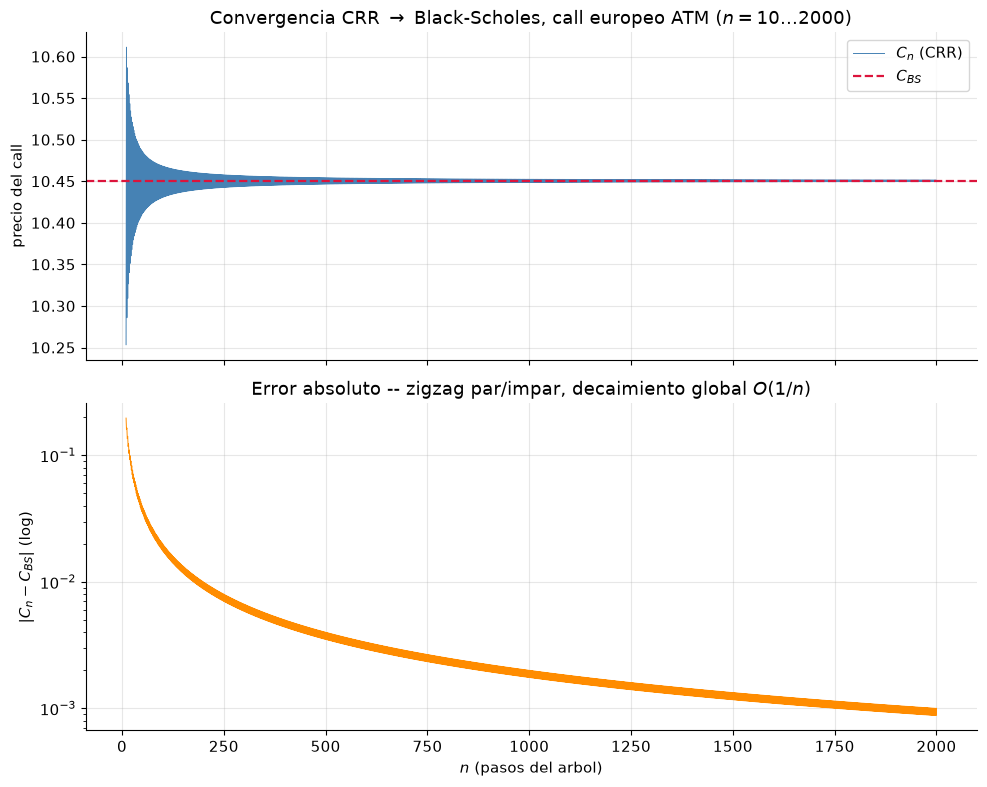

C_BS = 10.450584
C_n en n=10:   10.253409 (err -0.197175)
C_n en n=2000: 10.449584 (err -0.001000)


In [3]:
n_grid = np.arange(10, 2001)
bs_call = bs_price(S0, K, r, sigma, T, kind="call")
crr_prices = np.array([crr_euro_price(S0, K, r, sigma, T, n, kind="call") for n in n_grid])
abs_err = np.abs(crr_prices - bs_call)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(n_grid, crr_prices, color="steelblue", linewidth=0.7, label=r"$C_n$ (CRR)")
axes[0].axhline(bs_call, color="crimson", linestyle="--", linewidth=1.6, label=r"$C_{BS}$")
axes[0].set_ylabel("precio del call")
axes[0].set_title(r"Convergencia CRR $\to$ Black-Scholes, call europeo ATM ($n=10\ldots2000$)")
axes[0].legend()

axes[1].plot(n_grid, abs_err, color="darkorange", linewidth=0.7)
axes[1].set_yscale("log")
axes[1].set_xlabel("$n$ (pasos del arbol)")
axes[1].set_ylabel(r"$|C_n - C_{BS}|$ (log)")
axes[1].set_title("Error absoluto -- zigzag par/impar, decaimiento global $O(1/n)$")

fig.tight_layout()
plt.show()

print(f"C_BS = {bs_call:.6f}")
print(f"C_n en n=10:   {crr_prices[0]:.6f} (err {crr_prices[0]-bs_call:+.6f})")
print(f"C_n en n=2000: {crr_prices[-1]:.6f} (err {crr_prices[-1]-bs_call:+.6f})")

El precio oscila visiblemente alrededor de $C_{\text{BS}}$ en el panel superior (más notorio para $n$ pequeño), y el error en escala log del panel inferior confirma el zigzag: la envolvente decae de forma consistente con $O(1/n)$, pero dentro de esa envolvente hay dos trayectorias entrelazadas de magnitud y signo distintos — exactamente el fenómeno de la sección 2.2, que separamos en la Demo 2.

## 6. Demo 2 — Par vs. impar por separado

Separamos la secuencia $(C_n)$ en sus dos subsecuencias por paridad de $n$. Cada una, vista por separado, converge de forma **suave y monótona** (sin zigzag) hacia $C_{\text{BS}}$ — confirmando que la oscilación de la Demo 1 es enteramente un efecto de entrelazar dos secuencias suaves con constantes de error $c_1^{\text{par}} \neq c_1^{\text{impar}}$ (sección 2.2), no ruido numérico.

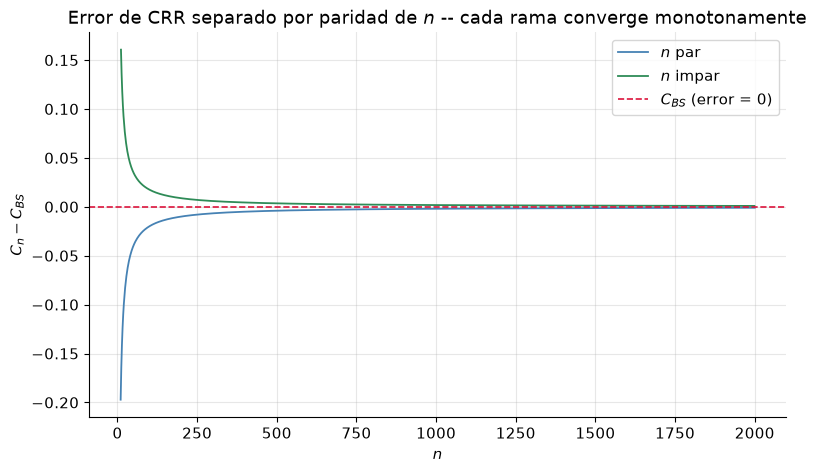

n=1000 (par):   error = -0.001999, error*n = -1.9995
n=999  (impar): error = +0.001755, error*n = +1.7529
Las constantes error*n son distintas y de signo opuesto entre ramas -- confirma c_1^par != c_1^impar.


In [4]:
even_mask = n_grid % 2 == 0
odd_mask = ~even_mask

fig, ax = plt.subplots()
ax.plot(n_grid[even_mask], crr_prices[even_mask] - bs_call, color="steelblue", linewidth=1.3, label="$n$ par")
ax.plot(n_grid[odd_mask], crr_prices[odd_mask] - bs_call, color="seagreen", linewidth=1.3, label="$n$ impar")
ax.axhline(0.0, color="crimson", linestyle="--", linewidth=1.2, label=r"$C_{BS}$ (error = 0)")
ax.set_xlabel("$n$")
ax.set_ylabel(r"$C_n - C_{BS}$")
ax.set_title("Error de CRR separado por paridad de $n$ -- cada rama converge monotonamente")
ax.legend()
plt.show()

err_even_1000 = crr_euro_price(S0, K, r, sigma, T, 1000, kind="call") - bs_call
err_odd_999 = crr_euro_price(S0, K, r, sigma, T, 999, kind="call") - bs_call
print(f"n=1000 (par):   error = {err_even_1000:+.6f}, error*n = {err_even_1000*1000:+.4f}")
print(f"n=999  (impar): error = {err_odd_999:+.6f}, error*n = {err_odd_999*999:+.4f}")
print("Las constantes error*n son distintas y de signo opuesto entre ramas -- confirma c_1^par != c_1^impar.")

## 7. Demo 3 — Extrapolación de Richardson $(n, 2n)$

Aplicamos $R_n = 2C_{2n} - C_n$ (sección 2.3) sobre la rama par ($n$ y $2n$ ambos pares), y comparamos el error absoluto $|R_n - C_{\text{BS}}|$ contra el error crudo $|C_n - C_{\text{BS}}|$ en escala log-log. Si la extrapolación funciona, la pendiente de $|R_n-C_{BS}|$ debe ser aproximadamente el doble (en escala log-log) de la de $|C_n - C_{BS}|$: $O(1/n^2)$ vs. $O(1/n)$.

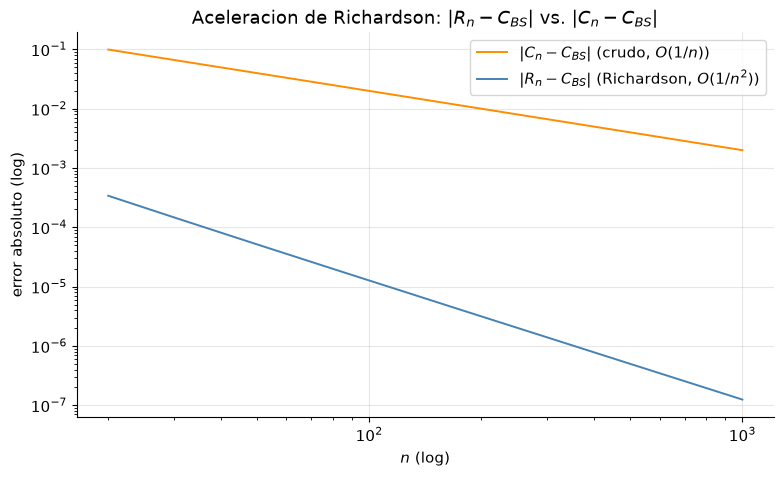

Pendiente log-log (crudo):     -0.999 (esperado ~ -1, error O(1/n))
Pendiente log-log (Richardson): -2.011 (esperado ~ -2, error O(1/n^2))

n=1000: |C_n - C_BS| = 1.999e-03, |R_n - C_BS| = 1.250e-07


In [5]:
n_richardson = np.arange(20, 1001, 2)  # even n, so 2n is also even
raw_err = np.array([abs(crr_euro_price(S0, K, r, sigma, T, n, kind="call") - bs_call) for n in n_richardson])
rich_err = np.array([abs(richardson_price(S0, K, r, sigma, T, n, kind="call") - bs_call) for n in n_richardson])

fig, ax = plt.subplots()
ax.loglog(n_richardson, raw_err, color="darkorange", linewidth=1.4, label=r"$|C_n - C_{BS}|$ (crudo, $O(1/n)$)")
ax.loglog(n_richardson, rich_err, color="steelblue", linewidth=1.4, label=r"$|R_n - C_{BS}|$ (Richardson, $O(1/n^2)$)")
ax.set_xlabel("$n$ (log)")
ax.set_ylabel("error absoluto (log)")
ax.set_title(r"Aceleracion de Richardson: $|R_n - C_{BS}|$ vs. $|C_n - C_{BS}|$")
ax.legend()
plt.show()

slope_raw = np.polyfit(np.log(n_richardson), np.log(raw_err), 1)[0]
slope_rich = np.polyfit(np.log(n_richardson), np.log(rich_err), 1)[0]
print(f"Pendiente log-log (crudo):     {slope_raw:.3f} (esperado ~ -1, error O(1/n))")
print(f"Pendiente log-log (Richardson): {slope_rich:.3f} (esperado ~ -2, error O(1/n^2))")
print(f"\nn=1000: |C_n - C_BS| = {raw_err[-1]:.3e}, |R_n - C_BS| = {rich_err[-1]:.3e}")

Las pendientes log-log confirman la teoría: la serie cruda decae con pendiente $\approx -1$ (error $O(1/n)$) mientras que la extrapolada decae con pendiente $\approx -2$ (error $O(1/n^2)$) — Richardson gana un orden completo de convergencia combinando dos evaluaciones que de todos modos calcularíamos por separado. Para $n=1000$, el error extrapolado es varios órdenes de magnitud menor que el crudo, sin refinar la malla del árbol — la ganancia viene enteramente de cancelar el término $c_1/n$ algebraicamente.

## 8. Validación

Tres capas, de la más fundamental a la más derivada:

1. **`bs_price` vs. `QuantLib`** (`AnalyticEuropeanEngine`, la fórmula cerrada exacta — sin discretización, así que no hay el problema de convención de probabilidad que 2.2 §7 tuvo con el árbol): mismo setup de `QuantLib` que 2.2 (fecha de evaluación fija, `Actual365Fixed`, curvas planas), `atol=1e-10`.
2. **$|C_{2000} - C_{\text{BS}}| < 5\times 10^{-3}$**: el precio CRR crudo con $n=2000$ debe estar a menos de medio centavo del límite continuo.
3. **$|R_n - C_{\text{BS}}| < |C_n - C_{\text{BS}}|$ para $n$ grandes**: la extrapolación de Richardson debe mejorar (no solo igualar) el error crudo.

In [6]:
import QuantLib as ql

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
calendar = ql.NullCalendar()
maturity = eval_date + 365

assert day_count.yearFraction(eval_date, maturity) == 1.0, "maturity must be exactly T=1.0"

spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))
rate_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, day_count))
div_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, 0.0, day_count))
vol_ts = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(eval_date, calendar, sigma, day_count))
process = ql.BlackScholesMertonProcess(spot_handle, div_ts, rate_ts, vol_ts)
engine = ql.AnalyticEuropeanEngine(process)

# --- Validation 1: bs_price vs QuantLib AnalyticEuropeanEngine, atol 1e-10 ---
print(f"{'kind':>5} | {'QuantLib':>16} | {'bs_price (inline)':>18} | {'diff':>10}")
print("-" * 58)
for kind, ql_kind in [("call", ql.Option.Call), ("put", ql.Option.Put)]:
    payoff = ql.PlainVanillaPayoff(ql_kind, K)
    exercise = ql.EuropeanExercise(maturity)
    option = ql.VanillaOption(payoff, exercise)
    option.setPricingEngine(engine)

    ql_p = option.NPV()
    py_p = bs_price(S0, K, r, sigma, T, kind=kind)
    diff = py_p - ql_p
    print(f"{kind:>5} | {ql_p:>16.10f} | {py_p:>18.10f} | {diff:>10.2e}")
    np.testing.assert_allclose(py_p, ql_p, atol=1e-10)

print("\nValidacion 1 pasada: bs_price coincide con QuantLib AnalyticEuropeanEngine a atol=1e-10.")

# --- Validation 2: |CRR(2000) - BS| < 5e-3 ---
err_2000 = abs(crr_euro_price(S0, K, r, sigma, T, 2000, kind="call") - bs_call)
print(f"\n|C_2000 - C_BS| = {err_2000:.6e}")
assert err_2000 < 5e-3, f"CRR(2000) too far from BS: {err_2000:.3e} >= 5e-3"
print("Validacion 2 pasada: |CRR(2000) - BS| < 5e-3.")

# --- Validation 3: |Richardson - BS| < |CRR - BS| for large n (even branch) ---
print()
for n_large in [500, 1000]:
    err_raw = abs(crr_euro_price(S0, K, r, sigma, T, n_large, kind="call") - bs_call)
    err_rich = abs(richardson_price(S0, K, r, sigma, T, n_large, kind="call") - bs_call)
    print(f"n={n_large:>4}: |C_n - C_BS| = {err_raw:.3e}, |R_n - C_BS| = {err_rich:.3e}")
    assert err_rich < err_raw, f"Richardson did not improve on raw CRR at n={n_large}"

print("\nValidacion 3 pasada: Richardson mejora estrictamente el error crudo para n grandes.")
print("\nTodas las validaciones pasaron.")

 kind |         QuantLib |  bs_price (inline) |       diff
----------------------------------------------------------
 call |    10.4505835722 |      10.4505835722 |  -1.24e-14
  put |     5.5735260223 |       5.5735260223 |   3.55e-15

Validacion 1 pasada: bs_price coincide con QuantLib AnalyticEuropeanEngine a atol=1e-10.

|C_2000 - C_BS| = 9.997967e-04
Validacion 2 pasada: |CRR(2000) - BS| < 5e-3.

n= 500: |C_n - C_BS| = 3.998e-03, |R_n - C_BS| = 5.011e-07
n=1000: |C_n - C_BS| = 1.999e-03, |R_n - C_BS| = 1.250e-07

Validacion 3 pasada: Richardson mejora estrictamente el error crudo para n grandes.

Todas las validaciones pasaron.


## Referencias

- Cox, J., Ross, S. & Rubinstein, M. (1979). *Option Pricing: A Simplified Approach*. Journal of Financial Economics, 7(3), 229-263.
- Black, F. & Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy, 81(3), 637-654.
- Leisen, D.P.J. & Reimer, M. (1996). *Binomial Models for Option Valuation -- Examining and Improving Convergence*. Applied Mathematical Finance, 3(4), 319-346.
- Diener, F. & Diener, M. (2004). *Asymptotics of the Price Oscillations of a European Call Option in a Tree Model*. Mathematical Finance, 14(2), 271-293.
- Shreve, S. (2004). *Stochastic Calculus for Finance I: The Binomial Asset Pricing Model*, cap. 3-4.
- Billingsley, P. (1995). *Probability and Measure*, 3rd ed. Wiley. Teorema 27.2 (Lindeberg-Feller).
- Durrett, R. (2019). *Probability: Theory and Examples*, 5th ed. Cambridge University Press. Teorema 3.4.10 (Lindeberg-Feller).